<a href="https://colab.research.google.com/github/lxlin27/DPS-Labs/blob/main/Lab_Digital_67080502297(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Lab: Digital Alchemy - ปฐมบทแห่งเสียงสังเคราะห์

ยินดีต้อนรับสู่ DSP Lab! วันนี้เราจะมาเสกตัวเลขใน Python ให้กลายเป็น "เสียง" ที่เราได้ยินได้
เราจะใช้แนวทาง **Code First, Math Later** คือสร้างเสียงให้สำเร็จก่อน แล้วค่อยไปเจาะลึกว่าตัวเลขเหล่านั้นทำงานอย่างไร

**เป้าหมายของวันนี้:**
1. สร้างเสียง Sine Wave พื้นฐาน
2. ทดลองเปลี่ยนรูปคลื่นเป็น Square Wave (เสียง 8-bit ดุดัน)
3. ฟังผลลัพธ์ของ Aliasing เมื่อ Sampling Rate ต่ำเกินไป
4. **Mini-Project:** สร้างเครื่องดนตรีจำลองที่เล่นเพลงสั้นๆ ได้!

In [7]:
# รันเซลล์นี้เพื่อนำเข้าไลบรารีที่จำเป็น
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# ตั้งค่าเริ่มต้นสำหรับกราฟ
plt.rcParams['figure.figsize'] = (10, 3)

## Part 1: The First Beep (Sine Wave)
เสียงพื้นฐานที่สุดในธรรมชาติและในคอมพิวเตอร์คือ **Sine Wave** เสียงนี้เกิดจากการแกว่งตัวของค่าทางคณิตศาสตร์อย่างสมบูรณ์แบบ

ในทางคณิตศาสตร์ สัญญาณเสียงดิจิทัลสามารถเขียนได้ด้วยสมการ:
$$y[n] = \sin\left(2\pi f \frac{n}{f_s}\right)$$

โดยที่:
* $f$ = ความถี่ (Frequency) มีหน่วยเป็น Hz (Hertz) ตัวกำหนดความสูงต่ำของเสียง
* $f_s$ = อัตราการสุ่มสัญญาณ (Sampling Rate) ปกติใช้ 44100 Hz
* $n$ = ลำดับของ Sample (Index)

**ภารกิจของคุณ:** เติมโค้ดในส่วน `[TODO]` ให้สมบูรณ์เพื่อสร้างฟังก์ชันที่คืนค่าเป็น Array ของคลื่น Sine

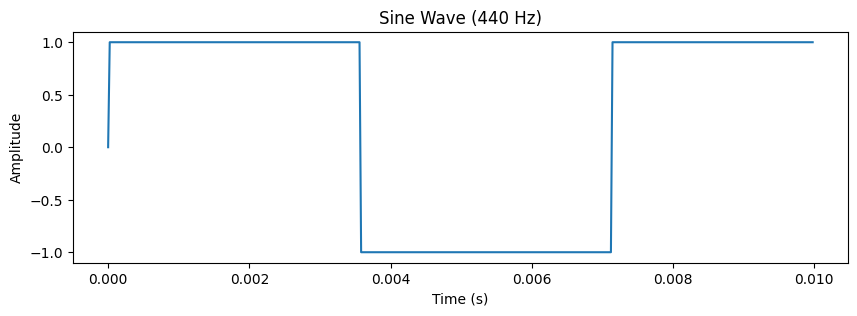

In [8]:
def generate_sine(freq, duration, sr=44100):
    """
    สร้างคลื่นเสียง Sine Wave
    freq: ความถี่ (Hz)
    duration: ความยาวของเสียง (วินาที)
    sr: Sampling rate (จำนวนข้อมูลต่อวินาที)
    """
    # 1. สร้างแกนเวลา t (สร้างตัวเลขตั้งแต่ 0 ถึง duration โดยมีจำนวนเท่ากับ sr * duration)
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)

    # 2. สร้างสมการ Sine Wave: y = sin(2 * pi * f * t)
    # [TODO]: เติมสมการคณิตศาสตร์โดยใช้ np.sin และ np.pi
    wave = np.sign(np.sin(2 * freq * t))

    return t, wave

# ทดสอบสร้างเสียงความถี่ 440 Hz (โน้ต A4) ความยาว 2 วินาที
t, my_wave = generate_sine(440, 2.0)

# แสดงผลกราฟ (ดูแค่ 0.01 วินาทีแรกเพื่อให้เห็นรูปคลื่นชัดเจน)
plt.plot(t[:441], my_wave[:441])
plt.title("Sine Wave (440 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# เล่นเสียง
# [TODO]: ลองเปลี่ยนค่า frequency เป็นตัวเลขอื่นๆ (เช่น 220, 880) แล้วฟังความแตกต่าง
display(Audio(my_wave, rate=44100))

## Part 2: Shaping the Sound (Square Wave)
คลื่น Sine อาจจะฟังดูนุ่มนวลเกินไป ถ้าเราอยากได้เสียงสังเคราะห์แบบเกมแฟมิคอมยุค 8-bit เราต้องใช้ **Square Wave** เทคนิคง่ายๆ ในการเปลี่ยน Sine เป็น Square คือการใช้ฟังก์ชัน `sign()` ของค่าที่ได้จาก Sine:
* ถ้าค่าเป็นบวก ให้กลายเป็น 1
* ถ้าค่าเป็นลบ ให้กลายเป็น -1

**ภารกิจของคุณ:**
สร้างฟังก์ชัน `generate_square` โดยประยุกต์ใช้ความรู้จาก `generate_sine`

In [11]:
def generate_square(freq, duration, sr=44100):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)

    # [TODO]: สร้างคลื่น Square Wave โดยใช้ np.sign() ครอบสมการ Sine Wave เดิม
    wave = np.sign(np.sin(2 * np.pi * freq * t))

    return t, wave

# ทดสอบสร้างเสียง Square Wave 440 Hz
t, sq_wave = generate_square(440, 1.0)
display(Audio(sq_wave, rate=44100))

## Part 3: Breaking the Matrix (Aliasing)
Sampling Rate ($f_s$) คือจำนวนครั้งต่อวินาทีที่คอมพิวเตอร์บันทึกจุดของคลื่นเสียง (มาตรฐาน CD คือ 44100 ครั้ง)
ถ้าเราพยายามบันทึกคลื่นความถี่สูงมากๆ ด้วย Sampling Rate ที่ต่ำเกินไป จะเกิดปรากฏการณ์ที่เรียกว่า **Aliasing** ซึ่งทำให้เสียงผิดเพี้ยนไปเป็นความถี่อื่น (เหมือนภาพล้อรถยนต์ที่ดูเหมือนหมุนกลับหลังในวิดีโอ)

**ภารกิจของคุณ:**
รันโค้ดด้านล่าง สังเกตและอธิบายว่าเกิดอะไรขึ้นเมื่อเราลด Sampling Rate ลง

In [12]:
# ความถี่สูง 5000 Hz
freq_high = 5000

# สร้างเสียงด้วย Sampling rate ปกติ (44100)
_, good_wave = generate_sine(freq_high, 1.0, sr=44100)
print("Normal Audio (fs=44100):")
display(Audio(good_wave, rate=44100))

# [TODO]: สร้างเสียงเดิม แต่ลด Sampling rate ลงเหลือ 8000
# สังเกตว่าเสียงที่ได้ยินยังแหลมเท่าเดิมหรือไม่?
bad_sr = 8000
_, bad_wave = generate_sine(freq_high, 1.0, sr=bad_sr)
print(f"Aliased Audio (fs={bad_sr}):")
display(Audio(bad_wave, rate=bad_sr))

Normal Audio (fs=44100):


Aliased Audio (fs=8000):


## Part 4: The 8-Bit Melody (Mini-Project)
ถึงเวลาประกอบร่าง! เราจะนำฟังก์ชันสร้างเสียงมาต่อกันเพื่อสร้างท่วงทำนองเพลง

ใน Python เราสามารถนำ Numpy Array มาต่อกันได้ด้วยคำสั่ง `np.concatenate([wave1, wave2, ...])`

**ภารกิจสุดท้าย:** ใช้ Dictionary ของโน้ตที่ให้มา สร้างโปรแกรมวนลูป (Loop) เพื่ออ่านโน้ตเพลงจากลิสต์ `melody` และสร้างคลื่นเสียงนำมาต่อกันเป็นเพลง 1 เพลง

In [16]:

# ความถี่ของโน้ตดนตรีมาตรฐาน
NOTES = {
    'C4': 261.63, 'D4': 293.66, 'E4': 329.63, 'F4': 349.23,
    'G4': 392.00, 'A4': 440.00, 'B4': 493.88, 'C5': 523.25,
    'D5': 587.33, 'E5': 659.25,
    'REST': 0.0
}


# กำหนดเพลง (โน้ต, ความยาวหน่วยเป็นวินาที)
melody = [
    ('G4', 0.5), ('A4', 0.5), ('B4', 0.5), ('A4', 0.5),
    ('G4', 0.5), ('E4', 0.5), ('D4', 1.0),

    ('G4', 0.5), ('A4', 0.5), ('B4', 0.5), ('A4', 0.5),
    ('G4', 0.5), ('E4', 0.5), ('D4', 1.0),

    ('E4', 0.5), ('G4', 0.5), ('A4', 0.5), ('G4', 0.5),
    ('E4', 0.5), ('D4', 0.5), ('C4', 1.0)
]
song_waves = []

# [TODO]: วนลูปอ่านค่าจาก melody
for note_name, duration in melody:
    freq = NOTES[note_name]

    if freq == 0:
        # ถ้าเป็น REST ให้สร้าง array ที่มีแต่เลข 0
        wave = np.zeros(int(44100 * duration))
    else:
        # [TODO]: เรียกใช้ generate_square (หรือ generate_sine)
        _, wave = generate_square(freq, duration)

    song_waves.append(wave)

# นำ Array ของเสียงมารวมกัน
final_song = np.concatenate(song_waves)

print("Twinkle Twinkle 8-Bit Star ✨")
display(Audio(final_song, rate=44100))

Twinkle Twinkle 8-Bit Star ✨
